In [1]:
import pandas as pd
import numpy as np

# Column names
columns = ['engine_id', 'cycle'] + \
          [f'op_setting_{i}' for i in range(1, 4)] + \
          [f'sensor_{i}' for i in range(1, 22)]

# Load train data
train_path = '../data/CMAPSSData/train_FD001.txt'

train_df = pd.read_csv(
    train_path,
    sep=' ',
    header=None
)

# Remove extra empty columns
train_df = train_df.iloc[:, :-2]
train_df.columns = columns

train_df.head()


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [2]:
# Calculate max cycle per engine
max_cycle = train_df.groupby('engine_id')['cycle'].max()

# Merge
train_df = train_df.merge(
    max_cycle.rename('max_cycle'),
    on='engine_id'
)

# RUL calculation
train_df['RUL'] = train_df['max_cycle'] - train_df['cycle']

# Cleanup
train_df.drop('max_cycle', axis=1, inplace=True)

train_df[['engine_id', 'cycle', 'RUL']].tail()


,engine_id,cycle,RUL
20626,100,196,4
20627,100,197,3
20628,100,198,2
20629,100,199,1
20630,100,200,0


In [3]:
train_df.isnull().sum().sum()
train_df['engine_id'].nunique()


100

In [4]:
# Drop non-informative sensors
non_informative_sensors = ['sensor_1', 'sensor_5', 'sensor_10', 
                           'sensor_16', 'sensor_18', 'sensor_19']

train_df_clean = train_df.drop(columns=non_informative_sensors)
train_df_clean.head()


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,...,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,641.82,1589.70,1400.60,21.61,554.36,...,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,642.15,1591.82,1403.14,21.61,553.75,...,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,642.35,1587.99,1404.20,21.61,554.26,...,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,642.35,1582.79,1401.87,21.61,554.45,...,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,642.37,1582.85,1406.22,21.61,554.00,...,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,187


In [5]:
from sklearn.preprocessing import MinMaxScaler

# Features to scale
feature_cols = [col for col in train_df_clean.columns if col not in ['engine_id', 'cycle', 'RUL']]

scaler = MinMaxScaler()
train_df_clean[feature_cols] = scaler.fit_transform(train_df_clean[feature_cols])

train_df_clean.head()


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,...,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,RUL
0,1,1,0.459770,0.166667,0.0,0.183735,0.406802,0.309757,1.0,0.726248,...,0.109755,0.369048,0.633262,0.205882,0.199608,0.363986,0.333333,0.713178,0.724662,191
1,1,2,0.609195,0.250000,0.0,0.283133,0.453019,0.352633,1.0,0.628019,...,0.100242,0.380952,0.765458,0.279412,0.162813,0.411312,0.333333,0.666667,0.731014,190
2,1,3,0.252874,0.750000,0.0,0.343373,0.369523,0.370527,1.0,0.710145,...,0.140043,0.250000,0.795309,0.220588,0.171793,0.357445,0.166667,0.627907,0.621375,189
3,1,4,0.540230,0.500000,0.0,0.343373,0.256159,0.331195,1.0,0.740741,...,0.124518,0.166667,0.889126,0.294118,0.174889,0.166603,0.333333,0.573643,0.662386,188
4,1,5,0.390805,0.333333,0.0,0.349398,0.257467,0.404625,1.0,0.668277,...,0.149960,0.255952,0.746269,0.235294,0.174734,0.402078,0.416667,0.589147,0.704502,187


In [6]:
import numpy as np

def create_sequences(df, sequence_length=30):
    sequences = []
    labels = []
    
    for engine_id in df['engine_id'].unique():
        engine_data = df[df['engine_id'] == engine_id]
        sensor_values = engine_data[feature_cols].values
        rul_values = engine_data['RUL'].values
        
        for i in range(len(engine_data) - sequence_length):
            sequences.append(sensor_values[i:i+sequence_length])
            labels.append(rul_values[i+sequence_length-1])
    
    return np.array(sequences), np.array(labels)

X_train, y_train = create_sequences(train_df_clean, sequence_length=30)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)


X_train shape: (17631, 30, 18)
y_train shape: (17631,)


In [7]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

print("Train sequences:", X_tr.shape)
print("Validation sequences:", X_val.shape)


Train sequences: (14104, 30, 18)
Validation sequences: (3527, 30, 18)


In [8]:
# Take last cycle of each engine
train_last_cycle = train_df_clean.groupby('engine_id').last().reset_index()

X_ml = train_last_cycle[feature_cols].values
y_ml = train_last_cycle['RUL'].values

print("ML X shape:", X_ml.shape)
print("ML y shape:", y_ml.shape)


ML X shape: (100, 18)
ML y shape: (100,)


In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Split
from sklearn.model_selection import train_test_split
X_tr_ml, X_val_ml, y_tr_ml, y_val_ml = train_test_split(
    X_ml, y_ml, test_size=0.2, random_state=42
)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_tr_ml, y_tr_ml)

# Predictions
y_pred_rf = rf.predict(X_val_ml)

# Evaluation
rmse = np.sqrt(mean_squared_error(y_val_ml, y_pred_rf))
mae = mean_absolute_error(y_val_ml, y_pred_rf)

print(f"Random Forest RMSE: {rmse:.2f}")
print(f"Random Forest MAE: {mae:.2f}")


Random Forest RMSE: 0.00
Random Forest MAE: 0.00


In [10]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [11]:
sequence_length = X_tr.shape[1]   # 30
num_features = X_tr.shape[2]      # number of sensors

model = Sequential([
    LSTM(100, input_shape=(sequence_length, num_features), return_sequences=True),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(1)   # Predict RUL
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()


C:\Users\megha\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 30, 100)             │          47,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 30, 100)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 50)                  │          30,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 77,851 (304.11 KB)

 Trainable params: 77,851 (304.11 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 32s 101ms/step - loss: 11314.7803 - mae: 86.5463 - val_loss: 9254.5674 - val_mae: 76.5222
Epoch 2/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 38s 91ms/step - loss: 9105.8643 - mae: 75.3795 - val_loss: 7795.2231 - val_mae: 68.9467
Epoch 3/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 21s 92ms/step - loss: 7714.0137 - mae: 68.0750 - val_loss: 6660.3896 - val_mae: 63.0961
Epoch 4/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 20s 90ms/step - loss: 6454.7632 - mae: 61.6016 - val_loss: 5790.1235 - val_mae: 58.7035
Epoch 5/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 21s 89ms/step - loss: 5735.7363 - mae: 58.0598 - val_loss: 5134.4360 - val_mae: 55.4927
Epoch 6/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 21s 91ms/step - loss: 5088.8481 - mae: 54.8076 - val_loss: 4655.3237 - val_mae: 53.1986
Epoch 7/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 20s 89ms/step - loss: 4533.7451 - mae: 52.5315 - val_loss: 4313.3701 - val_mae: 51.6470
Epoch 8/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 21s 91ms/step - loss: 4459.3892 - mae: 52.3445 - val_loss: 408

In [13]:
# Predictions
y_pred_lstm = model.predict(X_val)

# RMSE and MAE
rmse_lstm = np.sqrt(mean_squared_error(y_val, y_pred_lstm))
mae_lstm = mean_absolute_error(y_val, y_pred_lstm)

print(f"LSTM RMSE: {rmse_lstm:.2f}")
print(f"LSTM MAE: {mae_lstm:.2f}")


111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step
LSTM RMSE: 30.26
LSTM MAE: 19.86


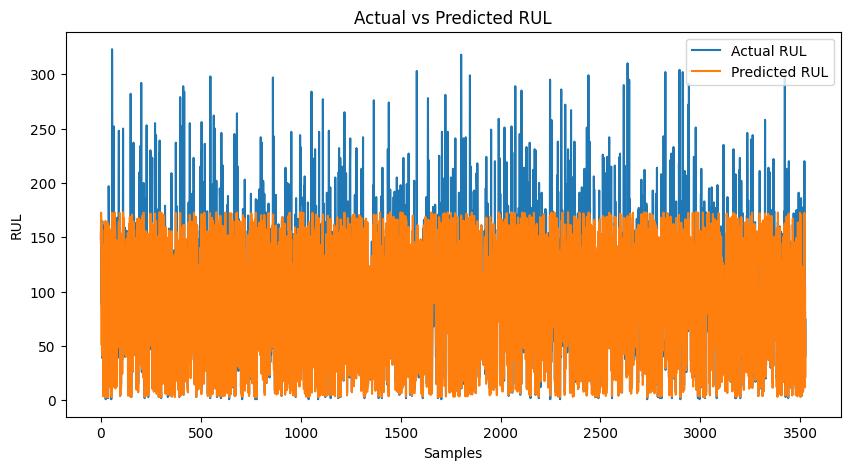

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_val, label='Actual RUL')
plt.plot(y_pred_lstm, label='Predicted RUL')
plt.xlabel('Samples')
plt.ylabel('RUL')
plt.title('Actual vs Predicted RUL')
plt.legend()
plt.show()


In [15]:
def categorize_rul(rul):
    if rul <= 20:
        return 'High'
    elif rul <= 50:
        return 'Medium'
    else:
        return 'Low'

# Apply to validation set
risk_levels = [categorize_rul(r) for r in y_val]

# Predicted risk
predicted_risk = [categorize_rul(r) for r in y_pred_lstm.flatten()]

import pandas as pd
risk_df = pd.DataFrame({
    'Actual_RUL': y_val,
    'Predicted_RUL': y_pred_lstm.flatten(),
    'Actual_Risk': risk_levels,
    'Predicted_Risk': predicted_risk
})

risk_df.head(10)


,Actual_RUL,Predicted_RUL,Actual_Risk,Predicted_Risk
0,149,144.951202,Low,Low
1,158,172.678864,Low,Low
2,129,162.261734,Low,Low
3,121,162.028595,Low,Low
4,88,50.655304,Low,Low
5,136,165.239166,Low,Low
6,39,40.929497,Medium,Medium
7,165,156.953659,Low,Low
8,106,137.928284,Low,Low
9,107,110.326103,Low,Low


In [16]:
from sklearn.metrics import accuracy_score, confusion_matrix

accuracy = accuracy_score(risk_levels, predicted_risk)
cm = confusion_matrix(risk_levels, predicted_risk, labels=['Low','Medium','High'])

print(f"Risk Classification Accuracy: {accuracy:.2f}")
print("Confusion Matrix:\n", cm)


Risk Classification Accuracy: 0.93
Confusion Matrix:
 [[2448   76    0]
 [  78  458   60]
 [   0   16  391]]


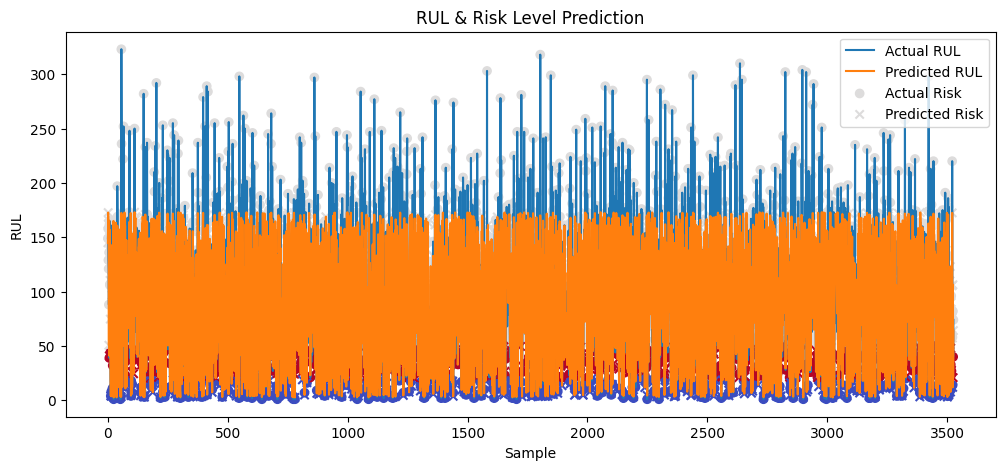

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_val, label='Actual RUL')
plt.plot(y_pred_lstm, label='Predicted RUL')
plt.scatter(range(len(y_val)), y_val, c=pd.Categorical(risk_levels).codes, cmap='coolwarm', label='Actual Risk')
plt.scatter(range(len(y_pred_lstm)), y_pred_lstm, c=pd.Categorical(predicted_risk).codes, marker='x', cmap='coolwarm', label='Predicted Risk')
plt.xlabel('Sample')
plt.ylabel('RUL')
plt.title('RUL & Risk Level Prediction')
plt.legend()
plt.show()


In [18]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense

input_seq = Input(shape=(sequence_length, num_features))
encoded = LSTM(64, activation='relu')(input_seq)
decoded = RepeatVector(sequence_length)(encoded)
decoded = LSTM(64, activation='relu', return_sequences=True)(decoded)
decoded = TimeDistributed(Dense(num_features))(decoded)

autoencoder = Model(inputs=input_seq, outputs=decoded)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 30, 18)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 64)                  │          21,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ repeat_vector (RepeatVector)         │ (None, 30, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 30, 64)              │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed (TimeDistributed)   │ (None, 30, 18)              │           1,170 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 55,442 (216.57 KB)

 Trainable params: 55,442 (216.57 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history = autoencoder.fit(
    X_tr, X_tr,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)


Epoch 1/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 25s 85ms/step - loss: 0.0722 - val_loss: 0.0092
Epoch 2/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 13s 75ms/step - loss: 0.0091 - val_loss: 0.0088
Epoch 3/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 13s 74ms/step - loss: 0.0088 - val_loss: 0.0087
Epoch 4/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 12s 67ms/step - loss: 0.0086 - val_loss: 0.0086
Epoch 5/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - loss: 0.0086 - val_loss: 0.0085
Epoch 6/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 0.0085 - val_loss: 0.0085
Epoch 7/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 0.0085 - val_loss: 0.0085
Epoch 8/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - loss: 0.0085 - val_loss: 0.0085
Epoch 9/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - loss: 0.0085 - val_loss: 0.0084
Epoch 10/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - loss: 0.0084 - val_loss: 0.0084
Epoch 11/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - loss: 0.0084 - val_loss: 0.0084
Epoch 12/50
177/177 ━━━━━━━━━━━━━━━━━

In [20]:
# Predict on validation set
X_val_pred = autoencoder.predict(X_val)

# Calculate reconstruction error per sequence
reconstruction_error = np.mean(np.square(X_val - X_val_pred), axis=(1,2))

# Threshold (mean + 3*std)
threshold = reconstruction_error.mean() + 3*reconstruction_error.std()
anomalies = reconstruction_error > threshold

print(f"Anomalies detected: {anomalies.sum()} out of {len(anomalies)} sequences")


111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step
Anomalies detected: 76 out of 3527 sequences


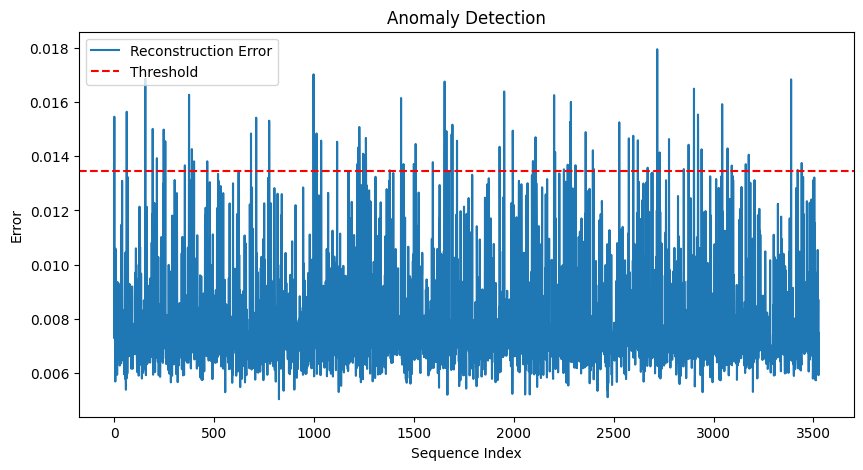

In [21]:
plt.figure(figsize=(10,5))
plt.plot(reconstruction_error, label='Reconstruction Error')
plt.axhline(threshold, color='r', linestyle='--', label='Threshold')
plt.xlabel('Sequence Index')
plt.ylabel('Error')
plt.title('Anomaly Detection')
plt.legend()
plt.show()

In [22]:
# Create models folder if not exists
import os
os.makedirs('../models', exist_ok=True)

# Save LSTM model
model.save('../models/lstm_model.h5')

# Save scaler
import joblib
joblib.dump(scaler, '../models/scaler.save')


['../models/scaler.save']